## Nerual Tangent


### Naive Combo

In [23]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/NeuralTangent/PureGen.csv')

best_ebm = 0.8319
best_ddpm = 0.8242

### Filter Data
df = df[df['Model'] == 'HLB_S']

### Compile Results
df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    if '_ReverseOnly' in data_key:
        label = 'PureGen_R'
    else:
        label = 'PureGen'

    # Get Steps
    diff_steps = int(data_key.split('DM_UNET')[1].split('_T[')[1].split(']')[0])

    mcmc_steps = int(data_key.split('Steps[')[1].split(']')[0])
    

    df_results.append({'Defense': label,
                        'Diff Steps': diff_steps,
                        'MCMC Steps': mcmc_steps,
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
# df_results

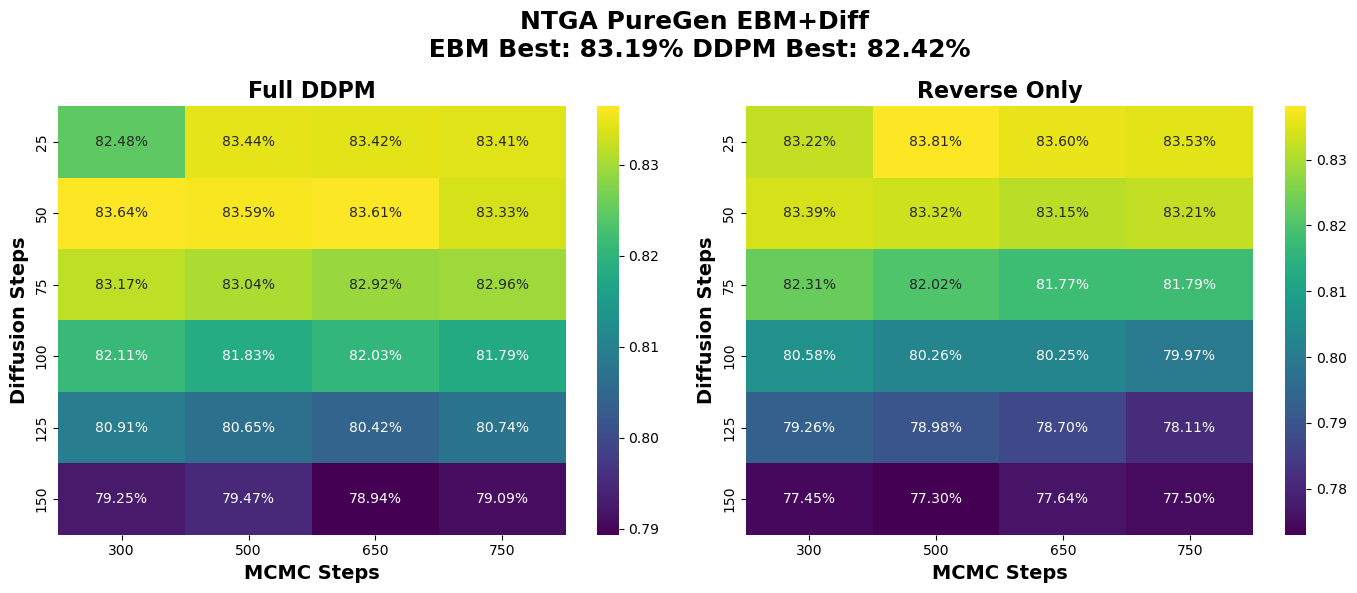

In [97]:
fig,axs = plt.subplots(1,2, figsize=(14,6))

# Full Diff
sns.heatmap(df_results[df_results['Defense'] == 'PureGen'].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[0,0])
axs[0,0].set_title('Full DDPM', fontsize=16, fontweight='bold')
axs[0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,0].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

# Reverse Only
sns.heatmap(df_results[df_results['Defense'] == 'PureGen_R'].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[1])
axs[1].set_title('Reverse Only', fontsize=16, fontweight='bold')
axs[1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

plt.suptitle(f'NTGA PureGen EBM+Diff\n EBM Best: {best_ebm:.2%} DDPM Best: {best_ddpm:.2%}', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig('PureGen_NTGA.pdf', dpi=300,bbox_inches='tight')

### Reps

In [74]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/NeuralTangent/PureGen_Reps.csv')

best_ebm = 0.8319
best_ddpm = 0.8242

### Filter Data
df = df[df['Model'] == 'HLB_S']

### Compile Results
df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    # Get Steps
    diff_steps = int(data_key.split('DM_UNET')[1].split('_T[')[1].split(']')[0])

    mcmc_steps = int(data_key.split('Steps[')[1].split(']')[0])
    
    reps = int(data_key.split('reps')[1])

    df_results.append({'Diff Steps': diff_steps,
                        'MCMC Steps': mcmc_steps,
                        'Reps': reps,
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                    'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
# df_results

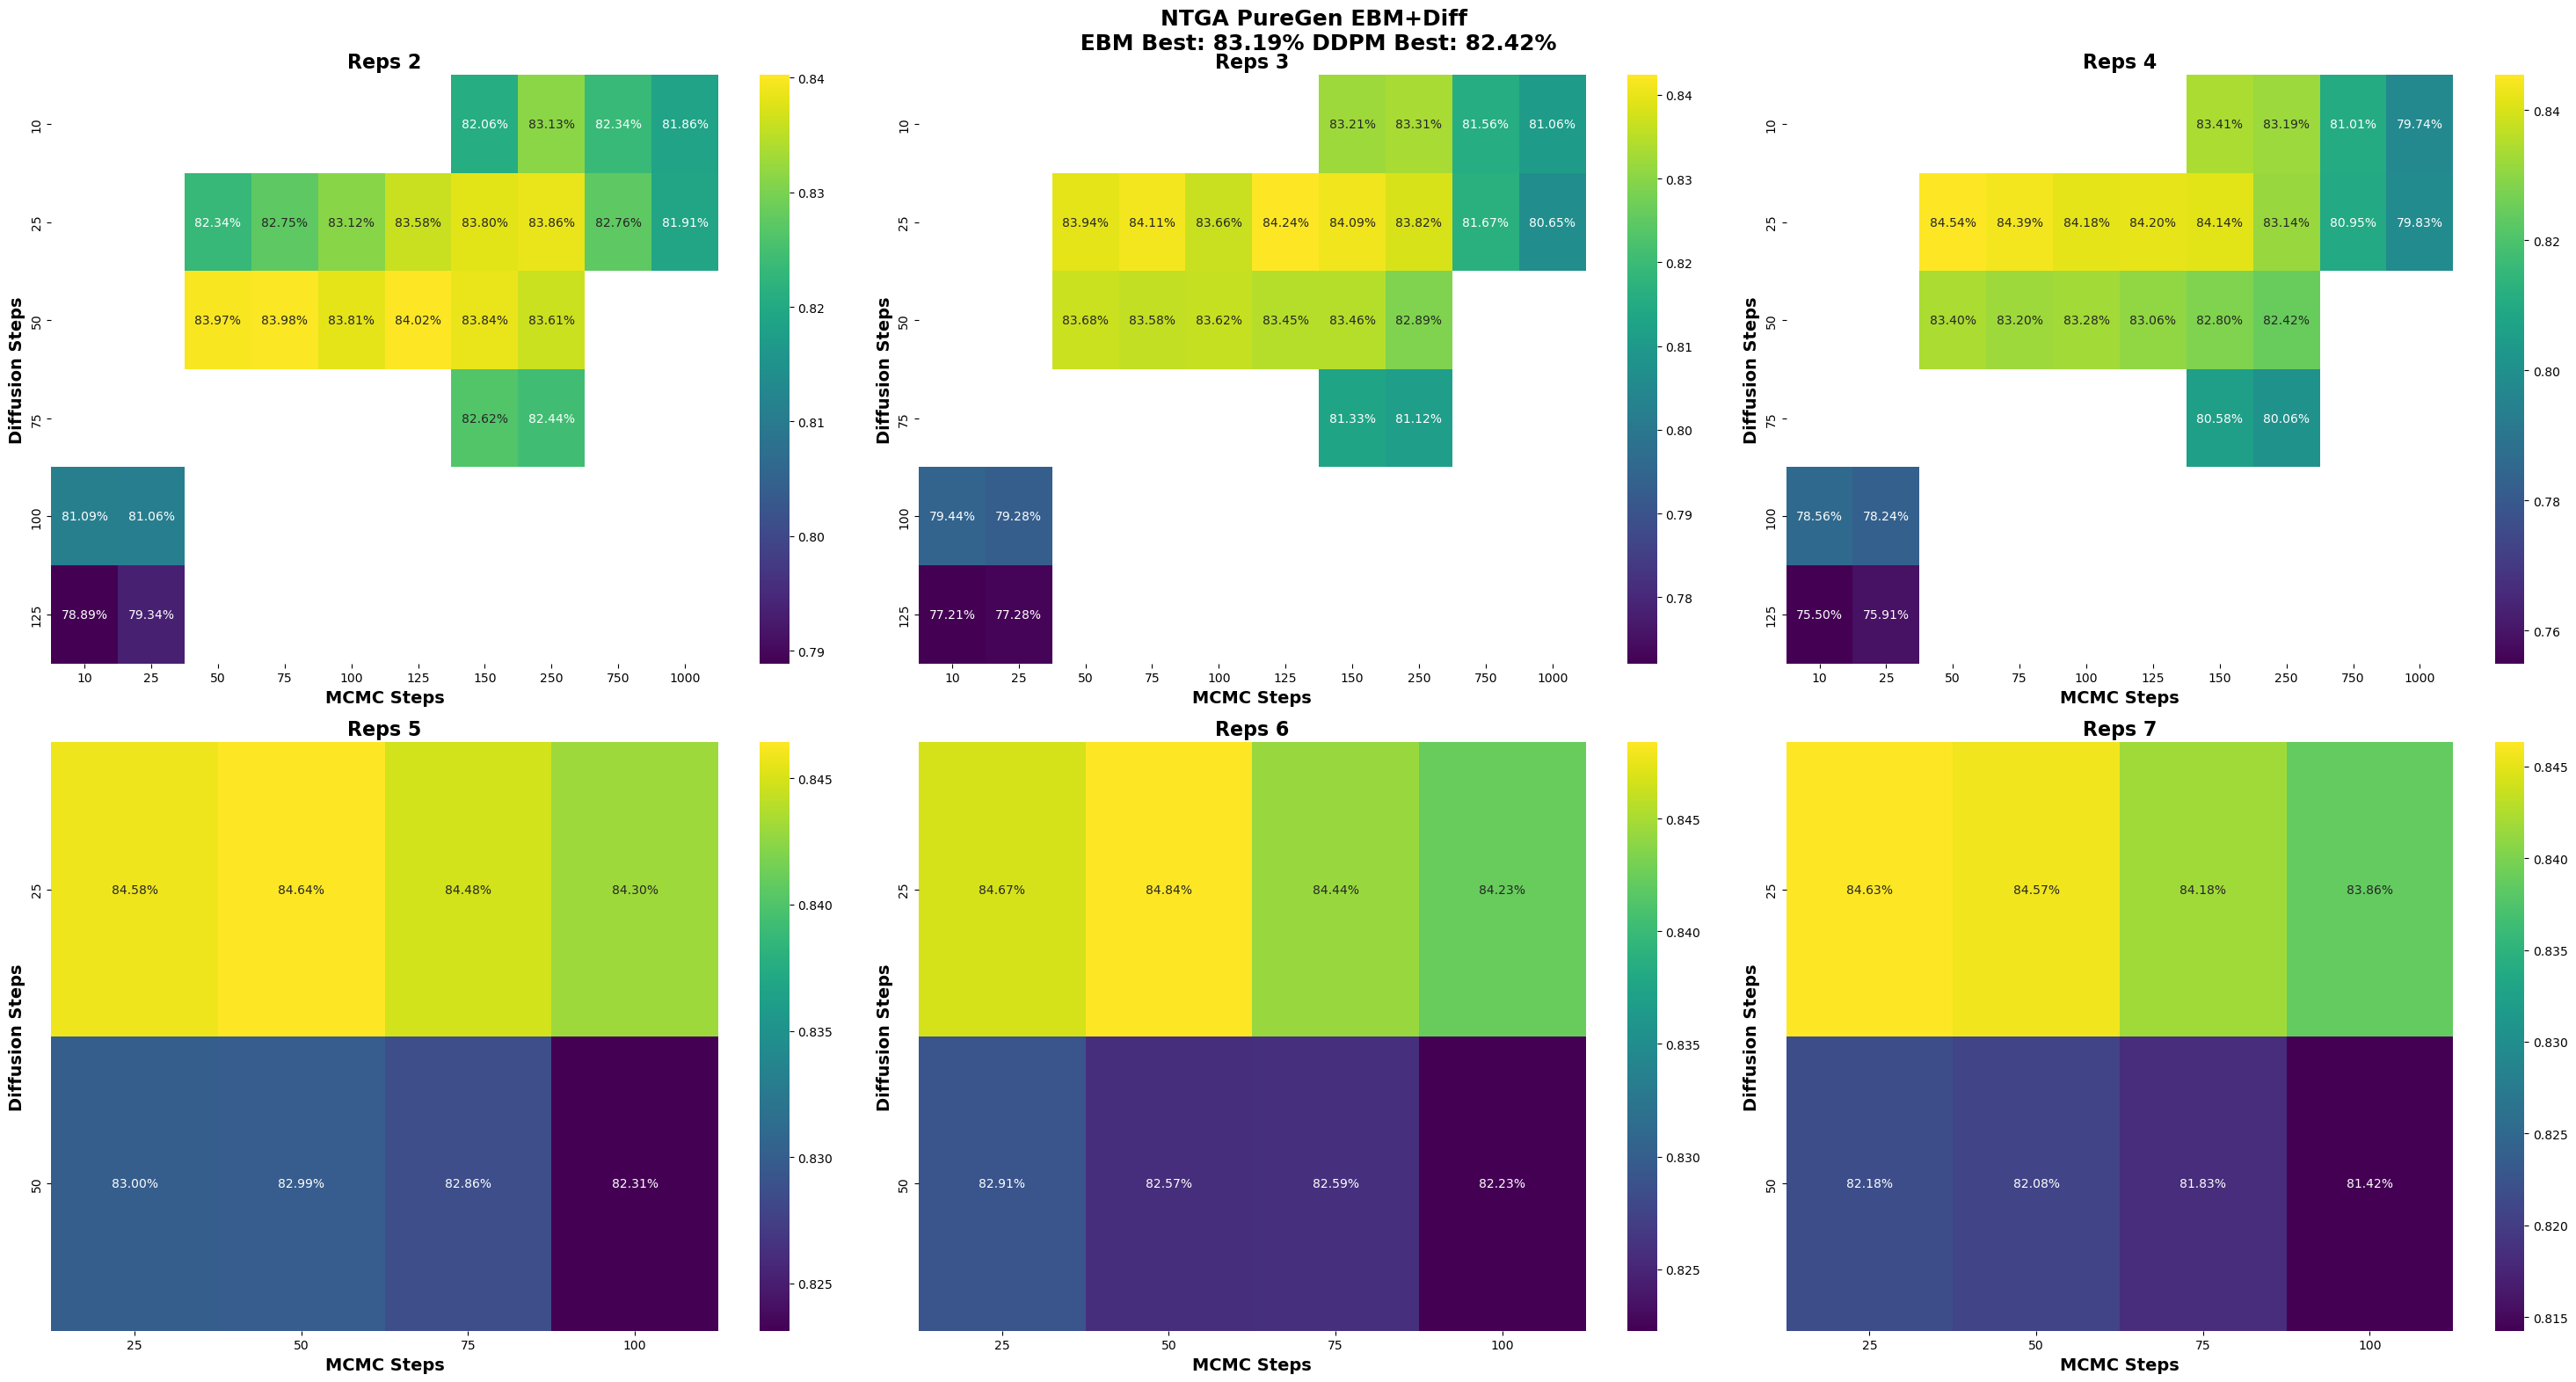

In [84]:
fig,axs = plt.subplots(2,3, figsize=(30,16))

sns.heatmap(df_results[df_results['Reps'] == 2].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[0,0])
axs[0,0].set_title('Reps 2', fontsize=16, fontweight='bold')
axs[0,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,0].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['Reps'] == 3].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[0,1])
axs[0,1].set_title('Reps 3', fontsize=16, fontweight='bold')
axs[0,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,1].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['Reps'] == 4].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[0,2])
axs[0,2].set_title('Reps 4', fontsize=16, fontweight='bold')
axs[0,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,2].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['Reps'] == 5].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[1,0])
axs[1,0].set_title('Reps 5', fontsize=16, fontweight='bold')
axs[1,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,0].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['Reps'] == 6].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[1,1])
axs[1,1].set_title('Reps 6', fontsize=16, fontweight='bold')
axs[1,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,1].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['Reps'] == 7].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[1,2])
axs[1,2].set_title('Reps 7', fontsize=16, fontweight='bold')
axs[1,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,2].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')


plt.suptitle(f'NTGA PureGen EBM+Diff\n EBM Best: {best_ebm:.2%} DDPM Best: {best_ddpm:.2%}', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.savefig('PureGen_NTGA.pdf', dpi=300,bbox_inches='tight')

## Narcissus

### Naive Combo

In [25]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PureGen.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

EPS = 16
MODEL = 'HLB_S'

### Filter Data
df = df[df['noise_eps_narcissus'] == EPS]
df = df[df['Model'] == MODEL]

best_ebm = [0.8821,.0873,.2305]
best_ddpm = [0.8616,.0520,.1332]

### Compile Results
df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    if '_ReverseOnly' in data_key:
        label = 'PureGen_R'
    else:
        label = 'PureGen'

    # Get Steps
    diff_steps = int(data_key.split('DM_UNET')[1].split('_T[')[1].split(']')[0])

    mcmc_steps = int(data_key.split('Steps[')[1].split(']')[0])
    

    df_results.append({'Defense': label,
                        'Diff Steps': diff_steps,
                        'MCMC Steps': mcmc_steps,
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
# df_results

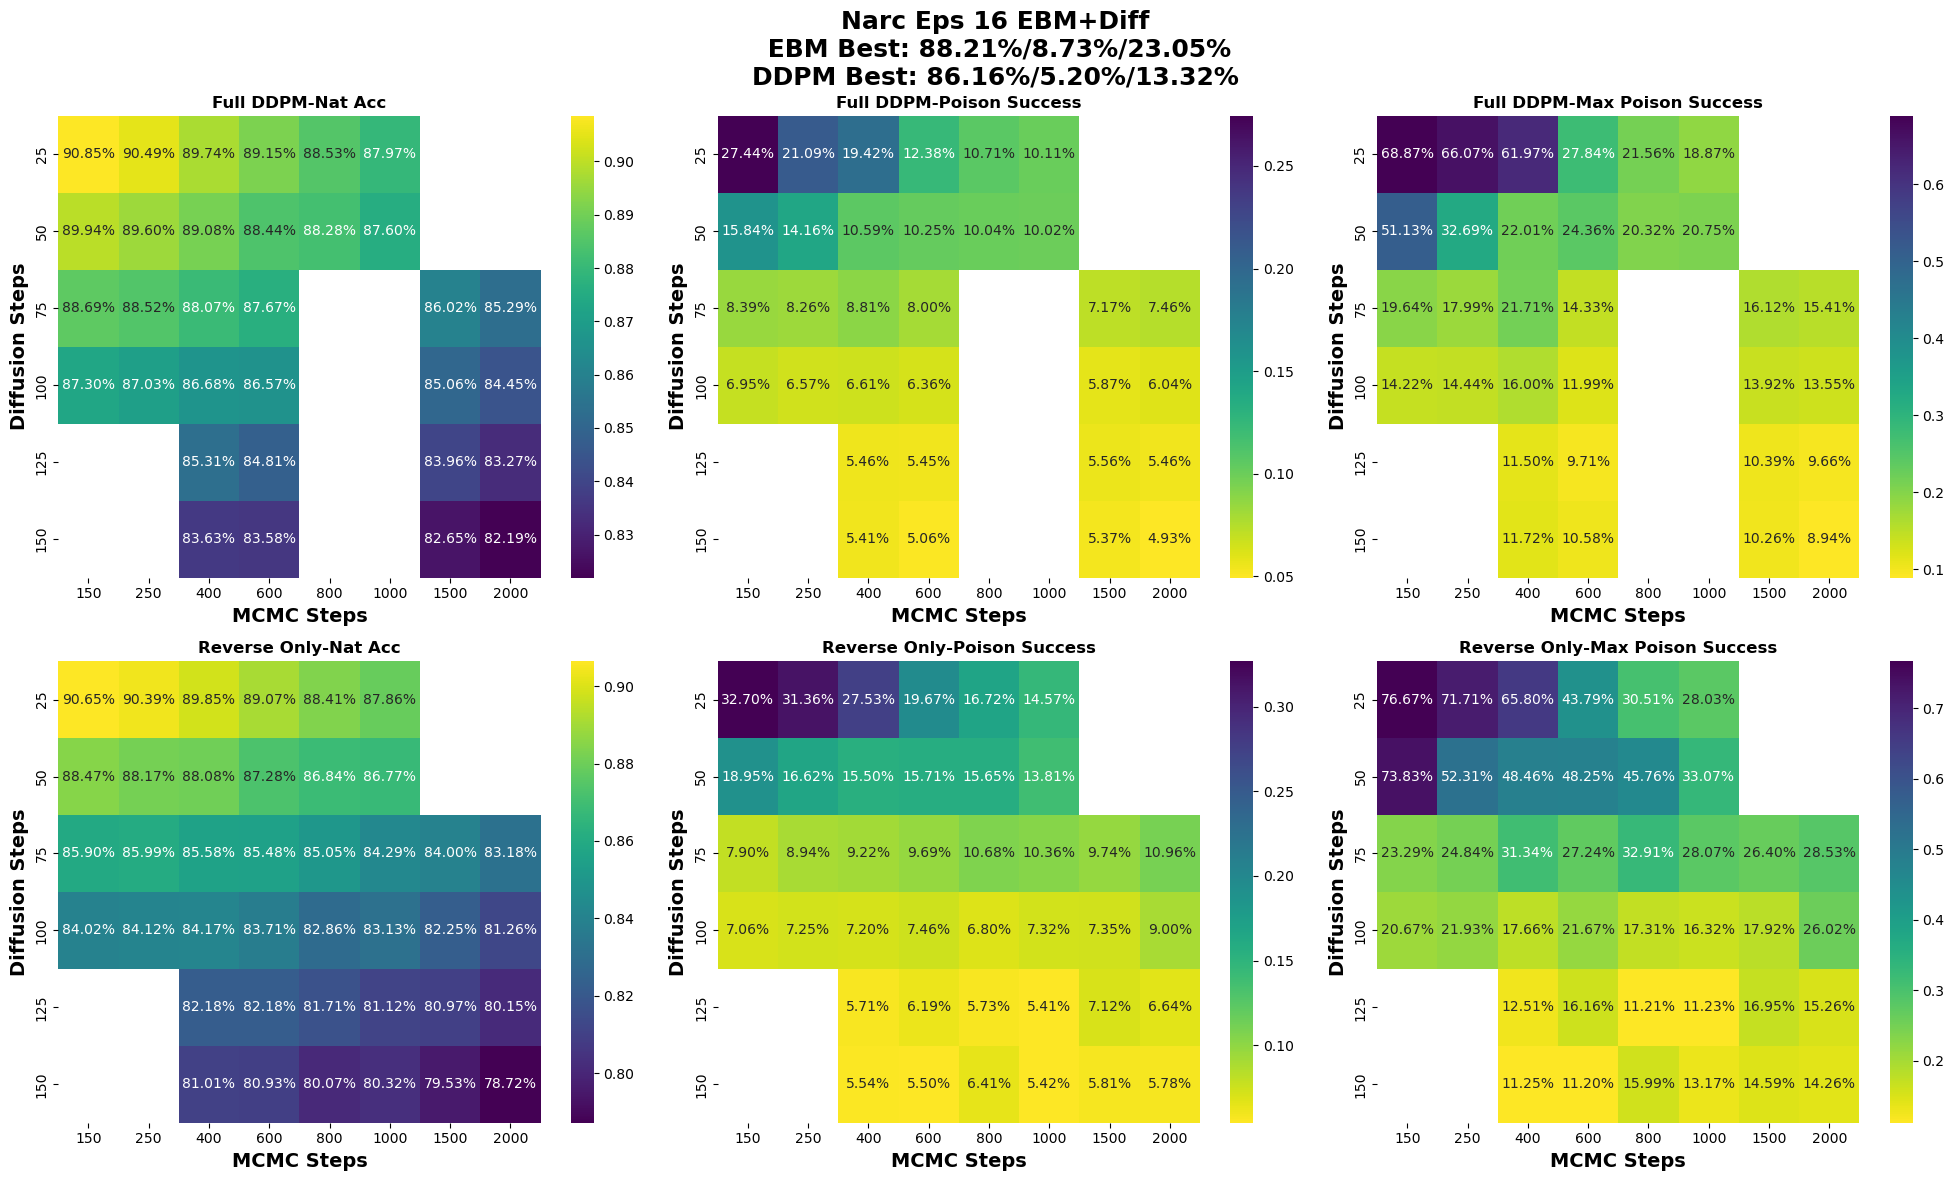

In [27]:
fig,axs = plt.subplots(2,3, figsize=(20,12))

# Full Diff Nat Acc
sns.heatmap(df_results[df_results['Defense'] == 'PureGen'].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[0,0])
axs[0,0].set_title('Full DDPM-Nat Acc', fontsize=12, fontweight='bold')
axs[0,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,0].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

# Full Diff Poison Success
sns.heatmap(df_results[df_results['Defense'] == 'PureGen'].pivot(index='Diff Steps', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[0,1])
axs[0,1].set_title('Full DDPM-Poison Success', fontsize=12, fontweight='bold')
axs[0,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,1].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

# Full Diff Max Poison Success
sns.heatmap(df_results[df_results['Defense'] == 'PureGen'].pivot(index='Diff Steps', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[0,2])
axs[0,2].set_title('Full DDPM-Max Poison Success', fontsize=12, fontweight='bold')
axs[0,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,2].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

# Reverse Only: Nat Acc
sns.heatmap(df_results[df_results['Defense'] == 'PureGen_R'].pivot(index='Diff Steps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[1,0])
axs[1,0].set_title('Reverse Only-Nat Acc', fontsize=12, fontweight='bold')
axs[1,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,0].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

# Reverse Only: Poison Success
sns.heatmap(df_results[df_results['Defense'] == 'PureGen_R'].pivot(index='Diff Steps', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[1,1])
axs[1,1].set_title('Reverse Only-Poison Success', fontsize=12, fontweight='bold')
axs[1,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,1].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')

# Reverse Only: Max Poison Success
sns.heatmap(df_results[df_results['Defense'] == 'PureGen_R'].pivot(index='Diff Steps', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[1,2])
axs[1,2].set_title('Reverse Only-Max Poison Success', fontsize=12, fontweight='bold')
axs[1,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,2].set_ylabel('Diffusion Steps', fontsize=14, fontweight='bold')



plt.suptitle(f'Narc Eps 16 EBM+Diff\n EBM Best: {best_ebm[0]:.2%}/{best_ebm[1]:.2%}/{best_ebm[2]:.2%}\nDDPM Best: {best_ddpm[0]:.2%}/{best_ddpm[1]:.2%}/{best_ddpm[2]:.2%}', fontsize=18, fontweight='bold')    

plt.tight_layout()

# plt.savefig('PureGen_Narc_16.pdf', dpi=300,bbox_inches='tight')

### Reps

In [15]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PureGen_Reps.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

EPS = 16
MODEL = 'HLB_S'

### Filter Data
df = df[df['noise_eps_narcissus'] == EPS]
df = df[df['Model'] == MODEL]

best_ebm = [0.8821,.0873,.2305]
best_ddpm = [0.8603,.0566,.1415]

### Compile Results
df_results = []
for data_key in df['Data Key'].unique():
    df_filt = df[df['Data Key'] == data_key]

    if '_ReverseOnly' in data_key:
        label = 'PureGen_R'
    else:
        label = 'PureGen'

    # Get Steps
    diff_steps = int(data_key.split('DM_UNET')[1].split('_T[')[1].split(']')[0])

    mcmc_steps = int(data_key.split('Steps[')[1].split(']')[0])

    reps = int(data_key.split('reps')[1])
    

    df_results.append({
                        'Diff Steps': diff_steps,
                        'MCMC Steps': mcmc_steps,
                        'Reps': reps,
                        'Nat Acc': df_filt['End Acc'].mean(),
                        'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                        'Poison Success': df_filt['P1 Acc'].mean(),
                        'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                        'Max Poison Success': df_filt['P1 Acc'].max(),
                        'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                        'Num Results': len(df_filt),
                    })
        
df_results = pd.DataFrame(df_results)
print(f'Num Rows: {len(df_results)}, Num Rows with Num Results not 10: {len(df_results[df_results["Num Results"] != 10])}')

# df_results
# df_results[df_results["Num Results"] != 10]

Num Rows: 192, Num Rows with Num Results not 10: 0


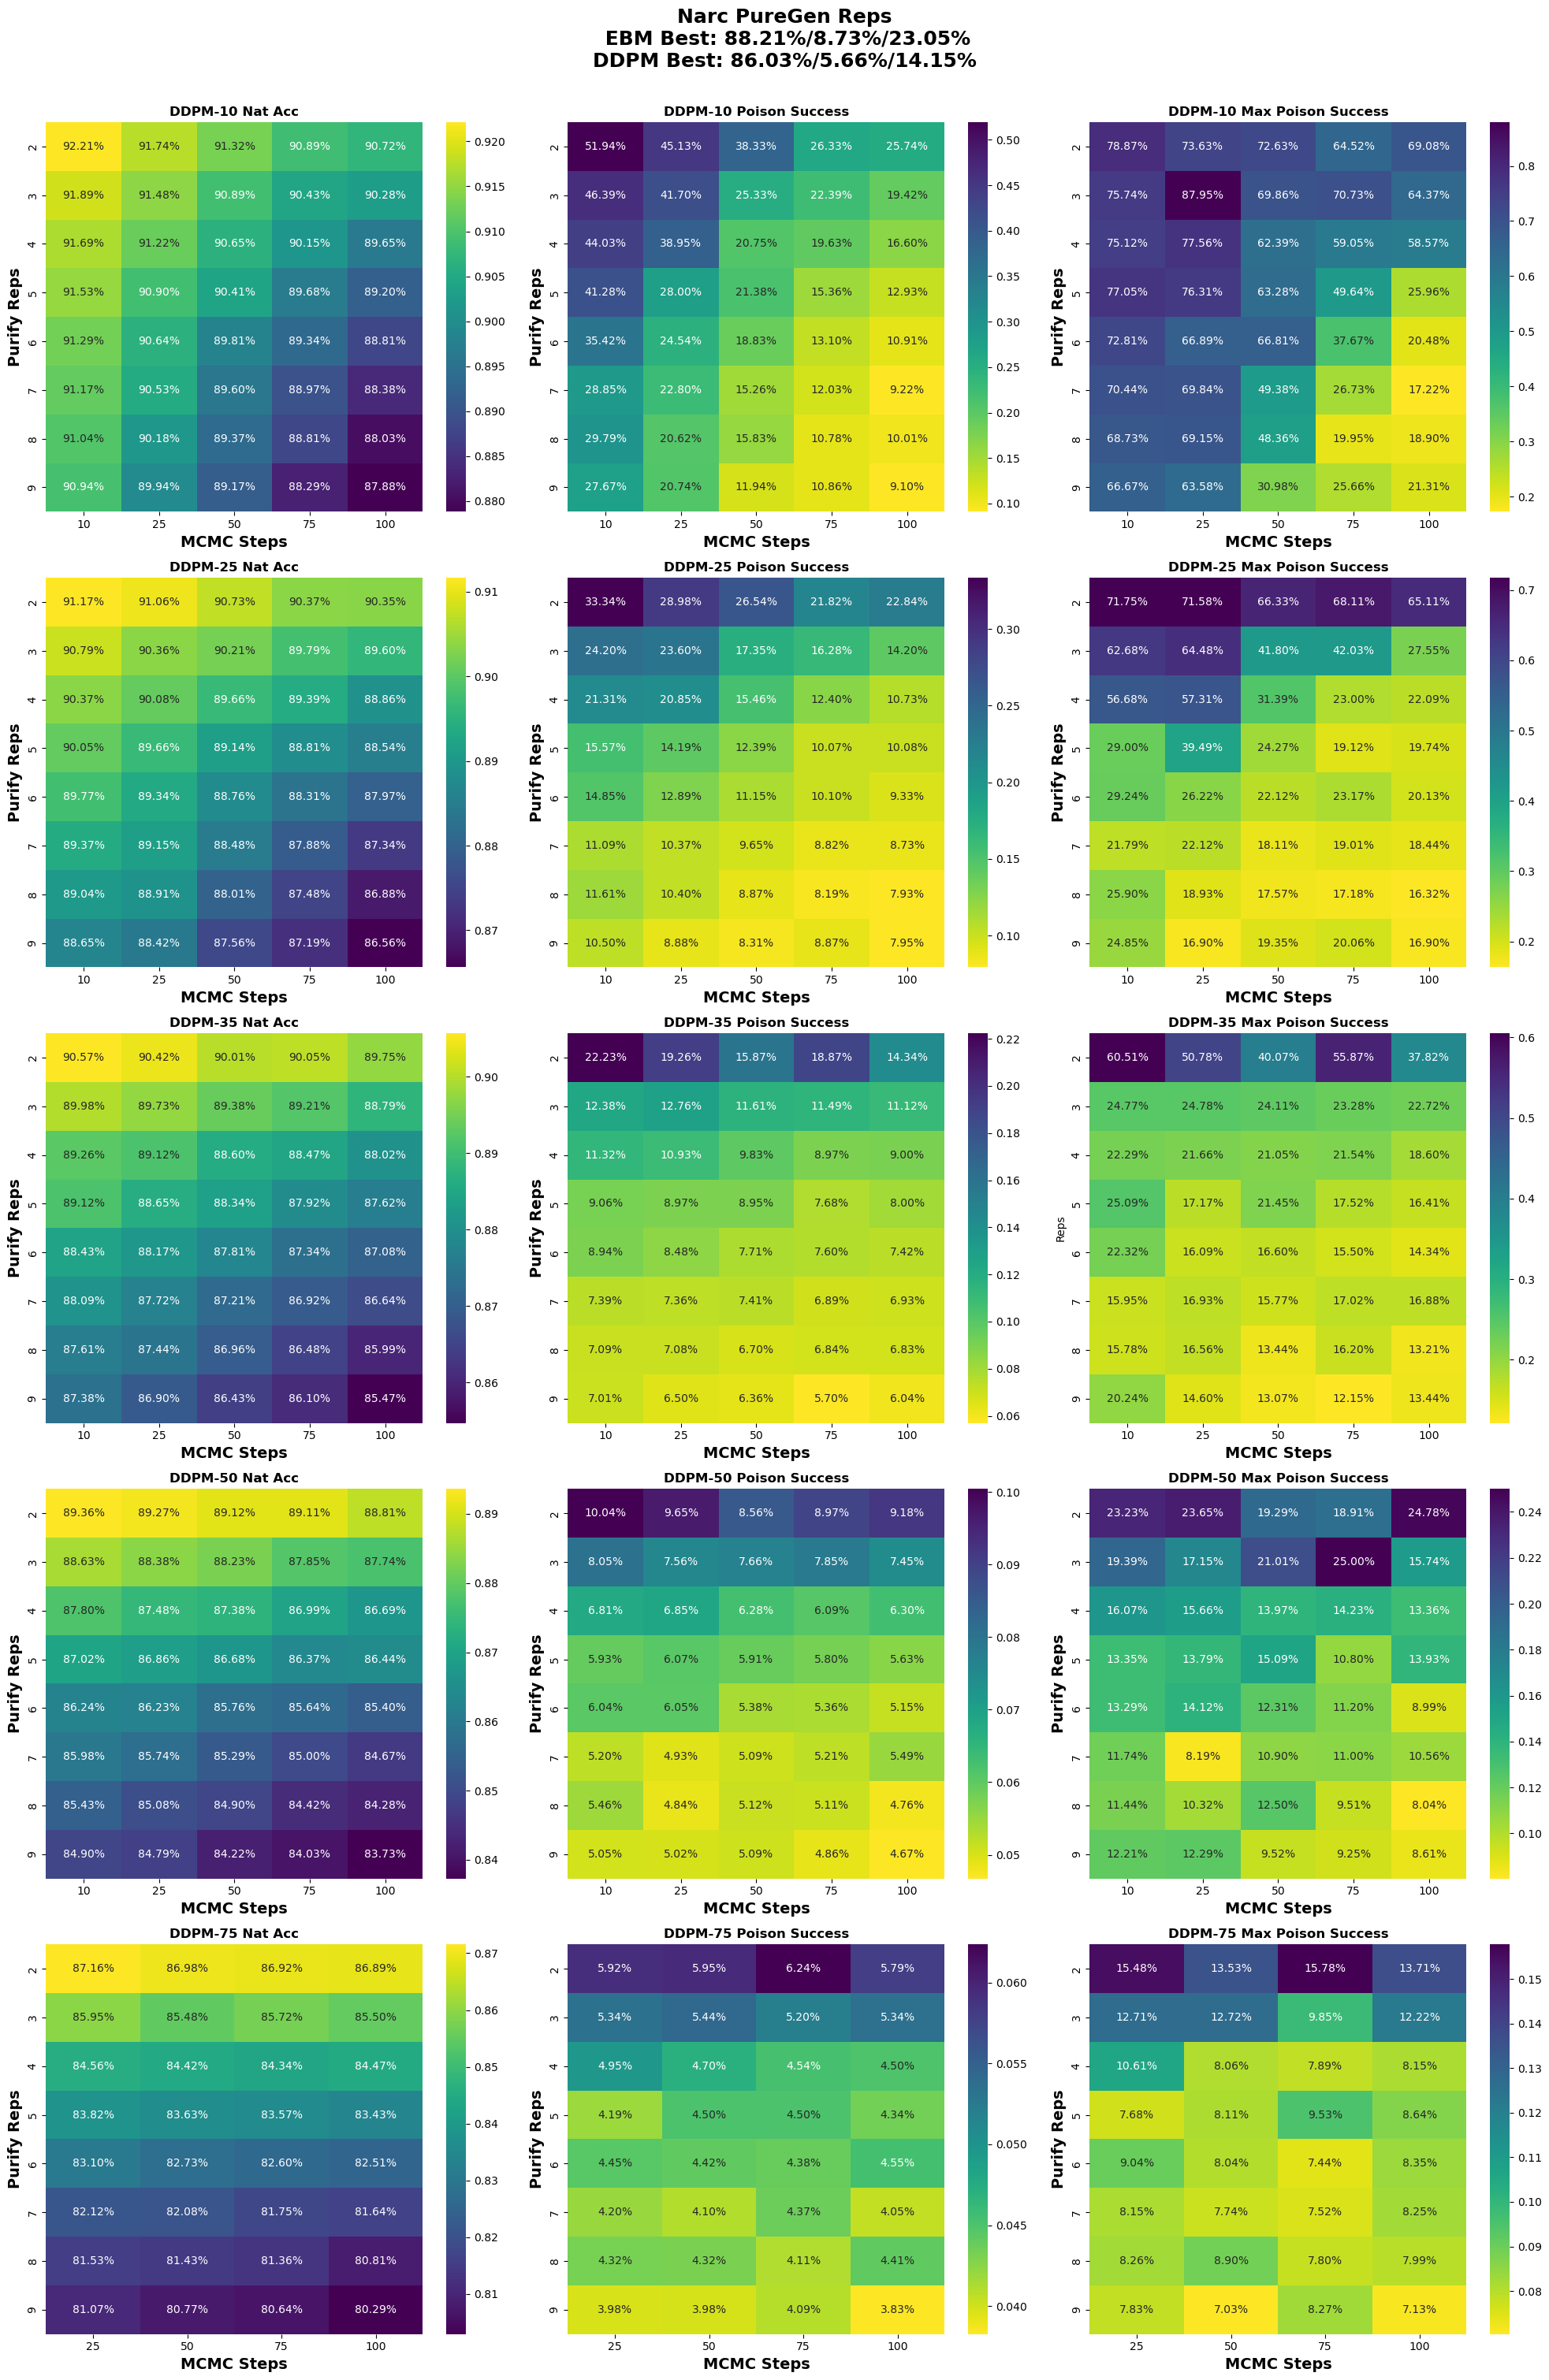

In [16]:
fig,axs = plt.subplots(5,3, figsize=(20,30))

# DM 10: Nat Acc
sns.heatmap(df_results[df_results['Diff Steps'] == 10].pivot(index='Reps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[0,0])
axs[0,0].set_title('DDPM-10 Nat Acc', fontsize=12, fontweight='bold')
axs[0,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,0].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 10: Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 10].pivot(index='Reps', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[0,1])
axs[0,1].set_title('DDPM-10 Poison Success', fontsize=12, fontweight='bold')
axs[0,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,1].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 10: Max Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 10].pivot(index='Reps', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[0,2])
axs[0,2].set_title('DDPM-10 Max Poison Success', fontsize=12, fontweight='bold')
axs[0,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,2].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 25: Nat Acc
sns.heatmap(df_results[df_results['Diff Steps'] == 25].pivot(index='Reps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[1,0])
axs[1,0].set_title('DDPM-25 Nat Acc', fontsize=12, fontweight='bold')
axs[1,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,0].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 25: Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 25].pivot(index='Reps', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[1,1])
axs[1,1].set_title('DDPM-25 Poison Success', fontsize=12, fontweight='bold')
axs[1,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,1].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 25: Max Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 25].pivot(index='Reps', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[1,2])
axs[1,2].set_title('DDPM-25 Max Poison Success', fontsize=12, fontweight='bold')
axs[1,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[1,2].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 35: Nat Acc
sns.heatmap(df_results[df_results['Diff Steps'] == 35].pivot(index='Reps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[2,0])
axs[2,0].set_title('DDPM-35 Nat Acc', fontsize=12, fontweight='bold')
axs[2,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[2,0].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 35: Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 35].pivot(index='Reps', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[2,1])
axs[2,1].set_title('DDPM-35 Poison Success', fontsize=12, fontweight='bold')
axs[2,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[2,1].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 35: Max Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 35].pivot(index='Reps', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[2,2])
axs[2,2].set_title('DDPM-35 Max Poison Success', fontsize=12, fontweight='bold')
axs[2,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')

# DM 50: Nat Acc
sns.heatmap(df_results[df_results['Diff Steps'] == 50].pivot(index='Reps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[3,0])
axs[3,0].set_title('DDPM-50 Nat Acc', fontsize=12, fontweight='bold')
axs[3,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[3,0].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 50: Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 50].pivot(index='Reps', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[3,1])
axs[3,1].set_title('DDPM-50 Poison Success', fontsize=12, fontweight='bold')
axs[3,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[3,1].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 50: Max Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 50].pivot(index='Reps', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[3,2])
axs[3,2].set_title('DDPM-50 Max Poison Success', fontsize=12, fontweight='bold')
axs[3,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[3,2].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 75: Nat Acc
sns.heatmap(df_results[df_results['Diff Steps'] == 75].pivot(index='Reps', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[4,0])
axs[4,0].set_title('DDPM-75 Nat Acc', fontsize=12, fontweight='bold')
axs[4,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[4,0].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 75: Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 75].pivot(index='Reps', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[4,1])
axs[4,1].set_title('DDPM-75 Poison Success', fontsize=12, fontweight='bold')
axs[4,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[4,1].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

# DM 75: Max Poison Success
sns.heatmap(df_results[df_results['Diff Steps'] == 75].pivot(index='Reps', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[4,2])
axs[4,2].set_title('DDPM-75 Max Poison Success', fontsize=12, fontweight='bold')
axs[4,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[4,2].set_ylabel('Purify Reps', fontsize=14, fontweight='bold')

plt.suptitle(f'Narc PureGen Reps\n EBM Best: {best_ebm[0]:.2%}/{best_ebm[1]:.2%}/{best_ebm[2]:.2%}\nDDPM Best: {best_ddpm[0]:.2%}/{best_ddpm[1]:.2%}/{best_ddpm[2]:.2%}', fontsize=18, fontweight='bold', y=1.005)   

plt.tight_layout()

# plt.savefig('PureGen_Narc_16.pdf', dpi=300,bbox_inches='tight')

### EBM Filter

In [36]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Data
df = pd.read_csv('/Users/sunaybhat/Documents/GitHub/Results/PureGen/From_Scratch/Narcissus/PureGen_Filt.csv')
df['Args'] = df['Args'].apply(lambda x: json.loads(x))
df = pd.concat([df.drop(['Args'], axis=1), df['Args'].apply(pd.Series)], axis=1)

EPS = 16
MODEL = 'HLB_S'

### Filter Data
df = df[df['noise_eps_narcissus'] == EPS]
df = df[df['Model'] == MODEL]

best_ebm = [0.8821,.0873,.2305]
best_ddpm = [0.8603,.0566,.1415]

### Compile Results
df_results = []
for filt in df['ebm_filter'].unique():
    for data_key in df['Data Key'].unique():
        if filt == None:
            df_filt = df[(df['Data Key'] == data_key) & (df['ebm_filter'].isnull())]
        else:
            df_filt = df[(df['Data Key'] == data_key) & (df['ebm_filter'] == filt)]

        if df_filt.empty:
            continue

        # Get Steps
        try:
            diff_steps = int(data_key.split('DM_UNET')[1].split('_T[')[1].split(']')[0])
        except:
            diff_steps = None
        try:
            mcmc_steps = int(data_key.split('Steps[')[1].split(']')[0])
        except:
            mcmc_steps = None
            

        df_results.append({
                            'Diff Steps': diff_steps,
                            'MCMC Steps': mcmc_steps,
                            'Filt': filt,
                            'Nat Acc': df_filt['End Acc'].mean(),
                            'Nat Acc Str': f"{df_filt['End Acc'].mean()*100:.2f}\u00B1{df_filt['End Acc'].std()*100:.2f}",
                            'Poison Success': df_filt['P1 Acc'].mean(),
                            'Poison Success Str': f"{df_filt['P1 Acc'].mean()*100:.2f}\u00B1{df_filt['P1 Acc'].std()*100:.2f}",
                            'Max Poison Success': df_filt['P1 Acc'].max(),
                            'Max Poison Success Str': f"{df_filt['P1 Acc'].max()*100:.2f}",
                            'Num Results': len(df_filt),
                        })
        
df_results = pd.DataFrame(df_results)
print(f'Num Rows: {len(df_results)}, Num Rows with Num Results not 10: {len(df_results[df_results["Num Results"] != 10])}')

# df_results
df_results[df_results["Num Results"] != 10]

Num Rows: 70, Num Rows with Num Results not 10: 0


,Diff Steps,MCMC Steps,Filt,Nat Acc,Nat Acc Str,Poison Success,Poison Success Str,Max Poison Success,Max Poison Success Str,Num Results


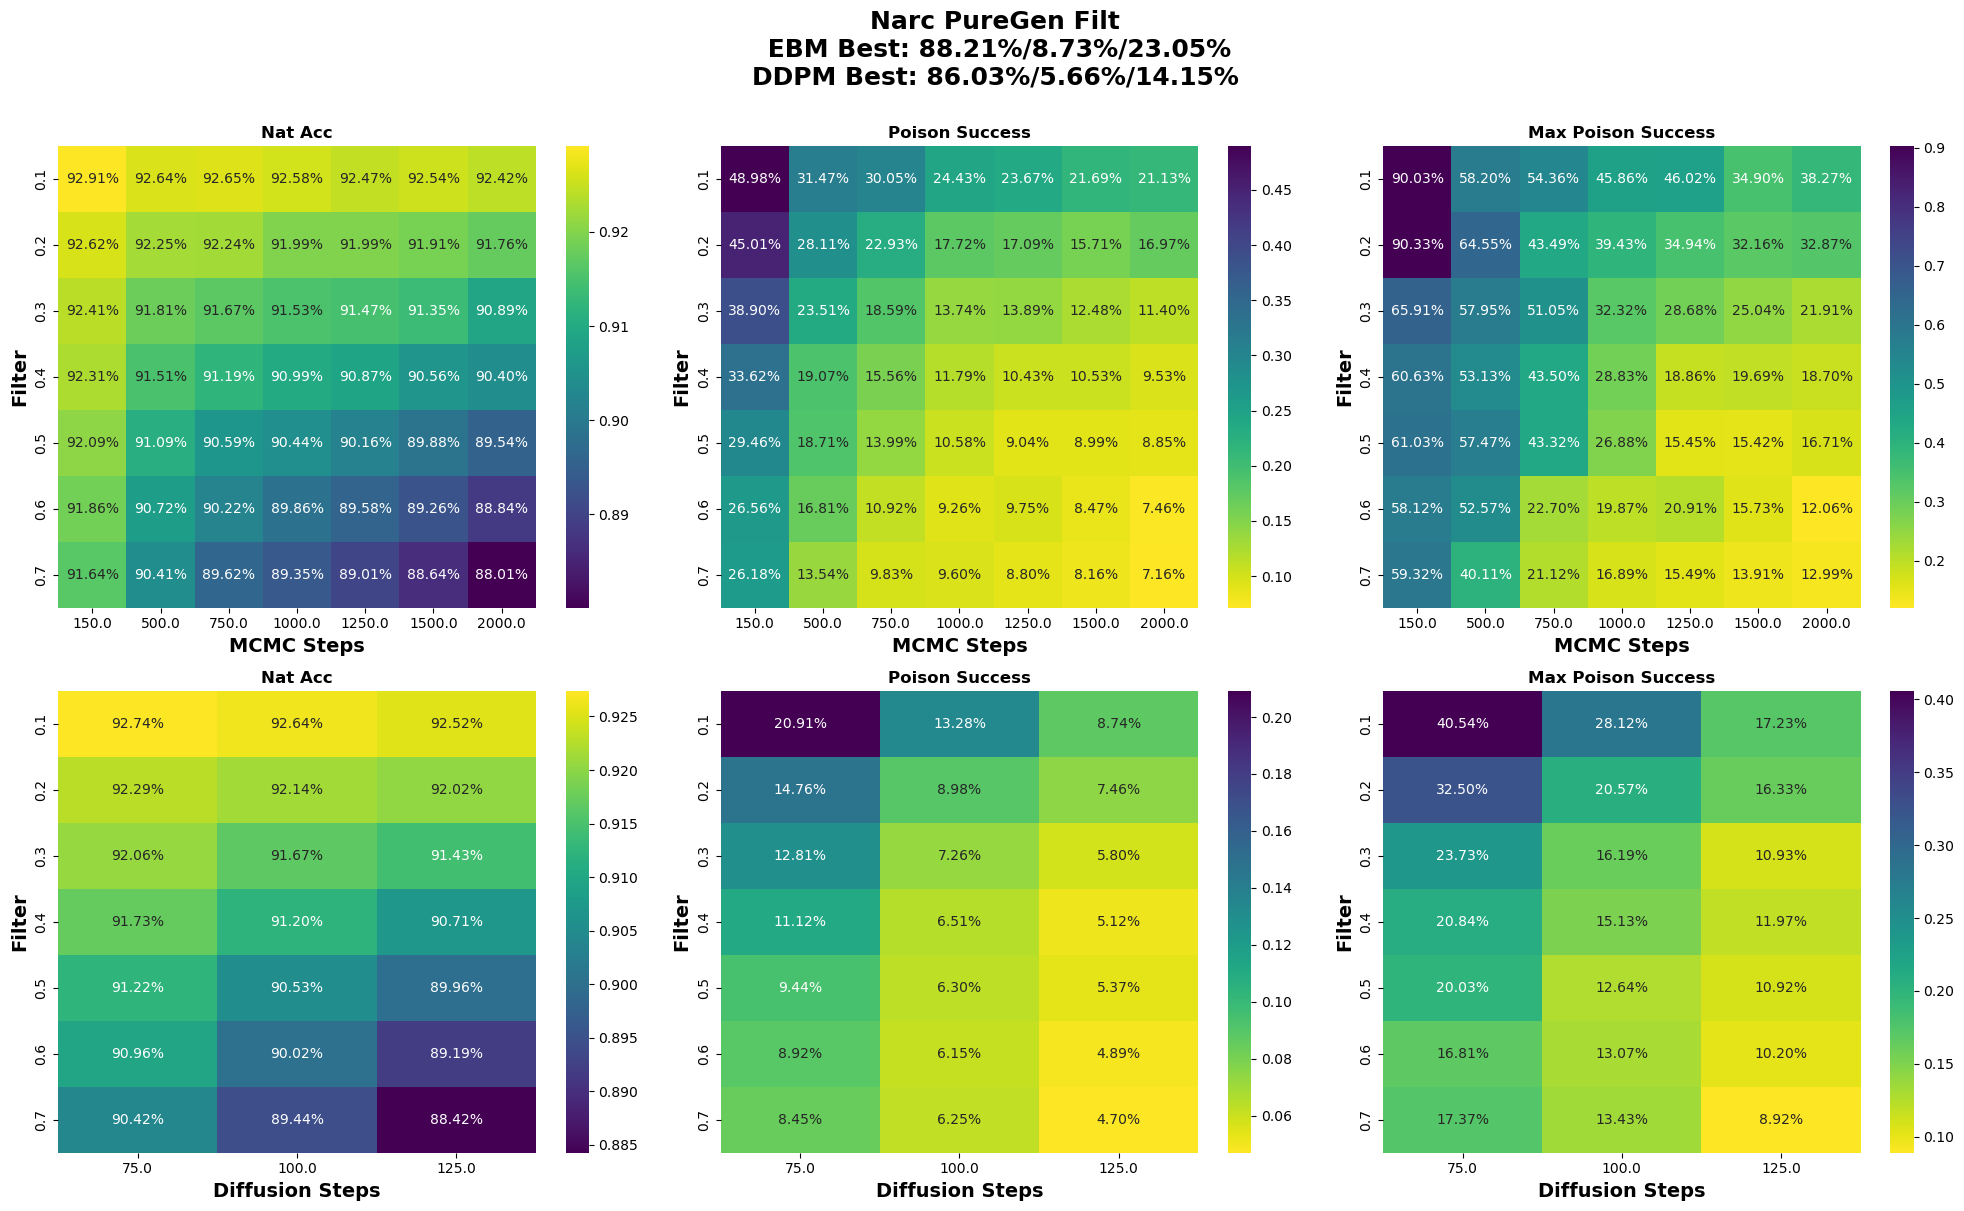

In [37]:

fig,axs = plt.subplots(2,3, figsize=(20,12))

### EBM Filtered MCMC
sns.heatmap(df_results[df_results['Diff Steps'].isna()].pivot(index='Filt', columns='MCMC Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[0,0])
axs[0,0].set_title('Nat Acc', fontsize=12, fontweight='bold')
axs[0,0].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,0].set_ylabel('Filter', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['Diff Steps'].isna()].pivot(index='Filt', columns='MCMC Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[0,1])
axs[0,1].set_title('Poison Success', fontsize=12, fontweight='bold')
axs[0,1].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,1].set_ylabel('Filter', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['Diff Steps'].isna()].pivot(index='Filt', columns='MCMC Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[0,2])
axs[0,2].set_title('Max Poison Success', fontsize=12, fontweight='bold')
axs[0,2].set_xlabel('MCMC Steps', fontsize=14, fontweight='bold')
axs[0,2].set_ylabel('Filter', fontsize=14, fontweight='bold')

### EBM Filtered Diffusion
sns.heatmap(df_results[df_results['MCMC Steps'].isna()].pivot(index='Filt', columns='Diff Steps', values='Nat Acc'), annot=True, fmt=".2%", cmap='viridis', ax=axs[1,0])
axs[1,0].set_title('Nat Acc', fontsize=12, fontweight='bold')
axs[1,0].set_xlabel('Diffusion Steps', fontsize=14, fontweight='bold')
axs[1,0].set_ylabel('Filter', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['MCMC Steps'].isna()].pivot(index='Filt', columns='Diff Steps', values='Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[1,1])
axs[1,1].set_title('Poison Success', fontsize=12, fontweight='bold')
axs[1,1].set_xlabel('Diffusion Steps', fontsize=14, fontweight='bold')
axs[1,1].set_ylabel('Filter', fontsize=14, fontweight='bold')

sns.heatmap(df_results[df_results['MCMC Steps'].isna()].pivot(index='Filt', columns='Diff Steps', values='Max Poison Success'), annot=True, fmt=".2%", cmap='viridis_r', ax=axs[1,2])
axs[1,2].set_title('Max Poison Success', fontsize=12, fontweight='bold')
axs[1,2].set_xlabel('Diffusion Steps', fontsize=14, fontweight='bold')
axs[1,2].set_ylabel('Filter', fontsize=14, fontweight='bold')

plt.suptitle(f'Narc PureGen Filt\n EBM Best: {best_ebm[0]:.2%}/{best_ebm[1]:.2%}/{best_ebm[2]:.2%}\nDDPM Best: {best_ddpm[0]:.2%}/{best_ddpm[1]:.2%}/{best_ddpm[2]:.2%}', fontsize=18, fontweight='bold', y=1.005)

plt.tight_layout()